# Noisy VQE Figures for Slides

Visualization notebook for synthetic-noise VQE caches. It starts with H2 only and can be compared with the noiseless statevector notebook.


## Setup


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.visualization.vqe_plots import (
    best_vqe_by_point,
    chemical_accuracy_config_table,
    ensure_figures_dir,
    load_latest_fci_curves,
    load_latest_vqe_results,
    plot_ansatz_comparison,
    plot_chemical_accuracy_rate,
    plot_dissociation_curve,
    plot_optimizer_comparison,
    plot_runtime_by_configuration,
    save_figure,
)

pd.set_option("display.max_columns", None)
output_dir = ensure_figures_dir("outputs/figures/slides_noisy")


## Load Latest Noisy Data


In [2]:
all_vqe_df = load_latest_vqe_results()
fci_df = load_latest_fci_curves(strategy="densest")

noisy_df = all_vqe_df[
    (all_vqe_df["molecule"] == "H2")
    & (all_vqe_df["run_label"].astype(str).str.startswith("noisy_synthetic"))
].copy()

statevector_df = all_vqe_df[
    (all_vqe_df["molecule"] == "H2")
    & (all_vqe_df["run_label"].fillna("statevector").astype(str).str.startswith("statevector"))
].copy()

print(f"Noisy rows: {len(noisy_df)}")
print(f"Statevector rows: {len(statevector_df)}")
noisy_df[["molecule", "basis", "ansatz", "optimizer", "success", "source_path"]].drop_duplicates().sort_values(["basis", "ansatz", "optimizer"])


Noisy rows: 216
Statevector rows: 252


,molecule,basis,ansatz,optimizer,success,source_path
114,H2,6-31g,efficient_su2,cobyla,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
115,H2,6-31g,efficient_su2,slsqp,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
116,H2,6-31g,efficient_su2,spsa,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
108,H2,6-31g,real_amplitudes,cobyla,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
109,H2,6-31g,real_amplitudes,slsqp,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
110,H2,6-31g,real_amplitudes,spsa,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
330,H2,sto-3g,efficient_su2,cobyla,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
331,H2,sto-3g,efficient_su2,slsqp,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
332,H2,sto-3g,efficient_su2,spsa,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...
324,H2,sto-3g,real_amplitudes,cobyla,True,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...


## Statevector baseline comparison

Use the best successful noisy and noiseless VQE point for each distance to estimate the practical noise penalty.


In [3]:
best_noisy_compare = best_vqe_by_point(noisy_df).assign(mode="Aer noisy")
best_statevector_compare = best_vqe_by_point(statevector_df).assign(mode="Statevector")

comparison_df = best_noisy_compare.merge(
    best_statevector_compare,
    on=["molecule", "basis", "distance"],
    suffixes=("_noisy", "_statevector"),
)
comparison_df["noise_penalty_kcal_mol"] = (
    comparison_df["abs_error_kcal_mol_noisy"] - comparison_df["abs_error_kcal_mol_statevector"]
)

comparison_cols = [
    "molecule", "basis", "distance",
    "ansatz_noisy", "reps_noisy", "optimizer_noisy",
    "abs_error_kcal_mol_noisy",
    "ansatz_statevector", "reps_statevector", "optimizer_statevector",
    "abs_error_kcal_mol_statevector", "noise_penalty_kcal_mol",
]
comparison_df[comparison_cols].sort_values(["basis", "distance"])


,molecule,basis,distance,ansatz_noisy,reps_noisy,optimizer_noisy,abs_error_kcal_mol_noisy,ansatz_statevector,reps_statevector,optimizer_statevector,abs_error_kcal_mol_statevector,noise_penalty_kcal_mol
0,H2,6-31g,0.350,real_amplitudes,1,spsa,198.377987,efficient_su2,1,slsqp,1.037762e+01,188.000365
1,H2,6-31g,0.500,real_amplitudes,1,cobyla,278.726211,efficient_su2,1,slsqp,1.244925e+01,266.276963
2,H2,6-31g,0.650,real_amplitudes,1,spsa,103.204479,efficient_su2,2,slsqp,1.441173e+01,88.792748
3,H2,6-31g,0.735,efficient_su2,1,spsa,186.603000,efficient_su2,2,slsqp,1.556580e+01,171.037204
4,H2,6-31g,0.900,real_amplitudes,2,spsa,226.589328,efficient_su2,1,slsqp,1.814529e+01,208.444041
5,H2,6-31g,1.100,real_amplitudes,1,spsa,129.043779,efficient_su2,1,slsqp,2.232961e+01,106.714171
6,H2,6-31g,1.400,efficient_su2,1,spsa,193.922298,real_amplitudes,2,slsqp,2.909343e+01,164.828871
7,H2,6-31g,1.800,real_amplitudes,1,spsa,95.390426,efficient_su2,1,slsqp,3.352863e+01,61.861798
8,H2,6-31g,2.200,real_amplitudes,1,spsa,143.269490,efficient_su2,2,slsqp,1.546373e+01,127.805759
9,H2,sto-3g,0.350,efficient_su2,1,spsa,25.188371,uccsd,1,cobyla,1.069523e-06,25.188369


outputs/figures/slides_noisy/noisy_vs_statevector_H2_6-31g.png


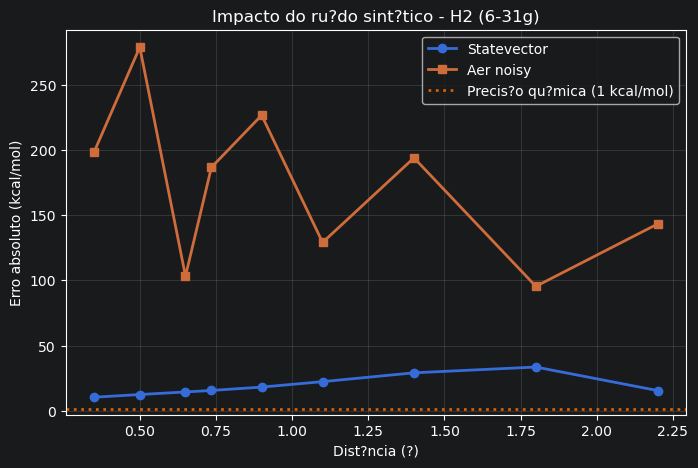

outputs/figures/slides_noisy/noisy_vs_statevector_H2_sto-3g.png


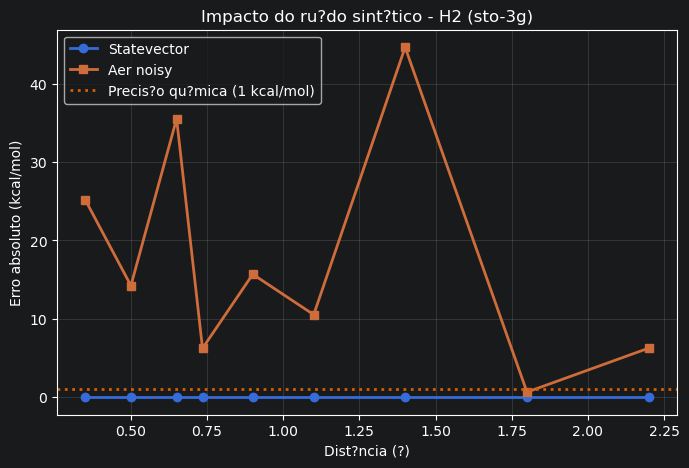

In [4]:
for basis in sorted(set(noisy_df["basis"]).intersection(statevector_df["basis"])):
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, df, marker in [
        ("Statevector", best_statevector_compare, "o"),
        ("Aer noisy", best_noisy_compare, "s"),
    ]:
        subset = df[df["basis"] == basis].sort_values("distance")
        if subset.empty:
            continue
        ax.plot(
            subset["distance"],
            subset["abs_error_kcal_mol"],
            marker=marker,
            linewidth=2,
            label=label,
        )
    ax.axhline(1.0, color="#7a003c", linestyle=":", linewidth=2, label="Precis?o qu?mica (1 kcal/mol)")
    ax.set_title(f"Impacto do ru?do sint?tico - H2 ({basis})")
    ax.set_xlabel("Dist?ncia (?)")
    ax.set_ylabel("Erro absoluto (kcal/mol)")
    ax.grid(True, alpha=0.25)
    ax.legend()
    path = save_figure(fig, output_dir, f"noisy_vs_statevector_H2_{basis}.png")
    print(path)
    plt.show()


## Best Noisy Results by Point


In [5]:
best_noisy_df = best_vqe_by_point(noisy_df)
best_noisy_df[[
    "molecule", "basis", "distance", "ansatz", "reps", "optimizer",
    "energy", "reference_energy", "abs_error_kcal_mol",
    "within_chemical_accuracy", "total_experiment_s",
]].sort_values(["basis", "distance"])


,molecule,basis,distance,ansatz,reps,optimizer,energy,reference_energy,abs_error_kcal_mol,within_chemical_accuracy,total_experiment_s
0,H2,6-31g,0.350,real_amplitudes,1,spsa,-0.519558,-0.835694,198.377987,False,10.457278
1,H2,6-31g,0.500,real_amplitudes,1,cobyla,-0.633685,-1.077864,278.726211,False,5.758561
2,H2,6-31g,0.650,real_amplitudes,1,spsa,-0.979697,-1.144164,103.204479,False,6.637518
3,H2,6-31g,0.735,efficient_su2,1,spsa,-0.854243,-1.151614,186.603000,False,11.442152
4,H2,6-31g,0.900,real_amplitudes,2,spsa,-0.779509,-1.140602,226.589328,False,12.278770
5,H2,6-31g,1.100,real_amplitudes,1,spsa,-0.905625,-1.111270,129.043779,False,16.867016
6,H2,6-31g,1.400,efficient_su2,1,spsa,-0.757740,-1.066775,193.922298,False,11.387958
7,H2,6-31g,1.800,real_amplitudes,1,spsa,-0.874121,-1.026136,95.390426,False,11.233630
8,H2,6-31g,2.200,real_amplitudes,1,spsa,-0.778479,-1.006794,143.269490,False,8.588903
9,H2,sto-3g,0.350,efficient_su2,1,spsa,-0.749129,-0.789269,25.188371,False,0.983727


## Noisy Configuration DataFrame


In [6]:
noisy_config_df = chemical_accuracy_config_table(noisy_df, only_accurate=False, statevector_only=False)

if noisy_config_df.empty:
    display(pd.DataFrame({
        "message": ["No successful noisy VQE rows were found for the configuration summary."],
        "noisy_rows": [len(noisy_df)],
    }))
else:
    display(noisy_config_df.sort_values([
        "molecule", "basis", "reached_chemical_accuracy", "accuracy_rate", "mean_error_kcal_mol"
    ], ascending=[True, True, False, False, True]))


,molecule,basis,ansatz,reps,optimizer,points,accurate_points,best_error_kcal_mol,mean_error_kcal_mol,median_error_kcal_mol,mean_time_s,best_distance,accuracy_rate,reached_chemical_accuracy,rank,is_best,config
8,H2,6-31g,real_amplitudes,1,spsa,9,0,95.390426,268.894523,198.377987,9.679185,1.80,0.000000,False,9,False,6-31g | RealAmplitudes | SPSA | reps=1
9,H2,6-31g,real_amplitudes,1,cobyla,9,0,197.996122,355.070187,281.259304,7.120561,1.40,0.000000,False,10,False,6-31g | RealAmplitudes | COBYLA | reps=1
10,H2,6-31g,efficient_su2,1,spsa,9,0,177.928593,391.633307,290.626621,11.564383,2.20,0.000000,False,11,False,6-31g | EfficientSU2 | SPSA | reps=1
11,H2,6-31g,real_amplitudes,2,spsa,9,0,190.961797,427.861573,442.896052,11.130280,0.65,0.000000,False,12,False,6-31g | RealAmplitudes | SPSA | reps=2
12,H2,6-31g,efficient_su2,1,cobyla,9,0,382.998933,518.459127,450.881760,6.942328,2.20,0.000000,False,13,False,6-31g | EfficientSU2 | COBYLA | reps=1
14,H2,6-31g,efficient_su2,2,spsa,9,0,223.394921,566.501159,586.593349,11.555761,2.20,0.000000,False,15,False,6-31g | EfficientSU2 | SPSA | reps=2
18,H2,6-31g,real_amplitudes,2,cobyla,9,0,266.255248,642.009379,659.690272,7.041532,1.10,0.000000,False,19,False,6-31g | RealAmplitudes | COBYLA | reps=2
19,H2,6-31g,efficient_su2,2,cobyla,9,0,631.246088,896.854109,859.312988,9.298888,1.40,0.000000,False,20,False,6-31g | EfficientSU2 | COBYLA | reps=2
20,H2,6-31g,efficient_su2,1,slsqp,9,0,1516.743137,1950.038168,1922.714761,287.646838,1.80,0.000000,False,21,False,6-31g | EfficientSU2 | SLSQP | reps=1
21,H2,6-31g,efficient_su2,2,slsqp,9,0,1609.864011,2007.879811,2032.328092,445.740856,0.65,0.000000,False,22,False,6-31g | EfficientSU2 | SLSQP | reps=2


## Noisy Dissociation Curves


outputs/figures/slides_noisy/noisy_dissociacao_H2_sto-3g.png


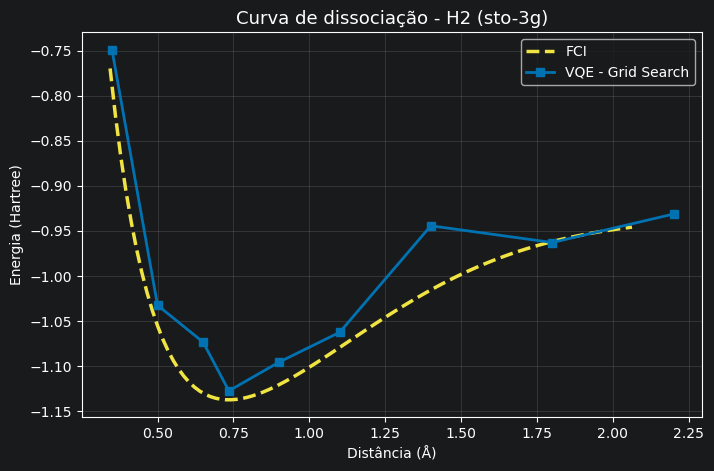

outputs/figures/slides_noisy/noisy_dissociacao_H2_6-31g.png


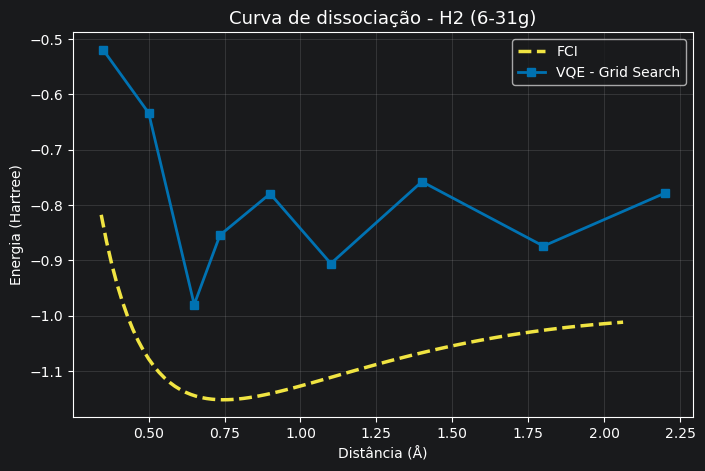

In [7]:
for molecule, basis in [("H2", "sto-3g"), ("H2", "6-31g")]:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_dissociation_curve(fci_df, noisy_df, molecule=molecule, basis=basis, ax=ax)
    path = save_figure(fig, output_dir, f"noisy_dissociacao_{molecule}_{basis}.png")
    print(path)
    plt.show()


## Noisy Ansatz Comparison


outputs/figures/slides_noisy/noisy_ansatz_H2_sto-3g_cobyla.png


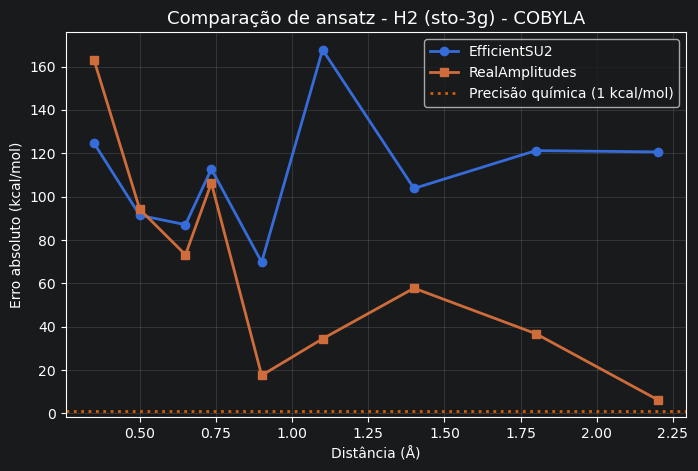

outputs/figures/slides_noisy/noisy_ansatz_H2_6-31g_cobyla.png


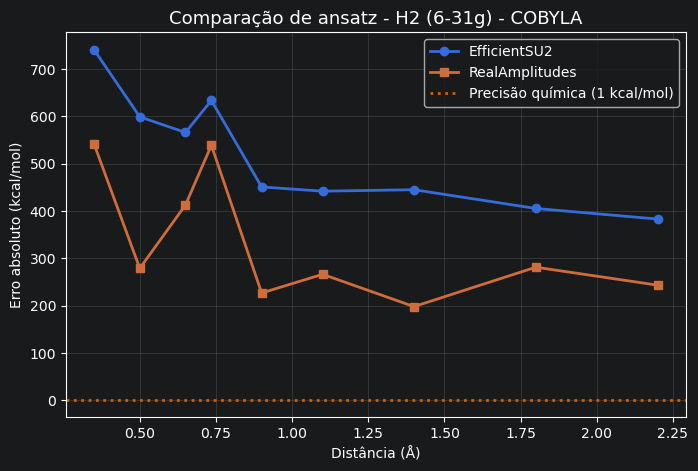

In [8]:
for molecule, basis, optimizer in [("H2", "sto-3g", "cobyla"), ("H2", "6-31g", "cobyla")]:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_ansatz_comparison(noisy_df, molecule=molecule, basis=basis, optimizer=optimizer, ax=ax)
    path = save_figure(fig, output_dir, f"noisy_ansatz_{molecule}_{basis}_{optimizer}.png")
    print(path)
    plt.show()


## Noisy Optimizer Comparison


outputs/figures/slides_noisy/noisy_otimizadores_H2_sto-3g_efficient_su2.png


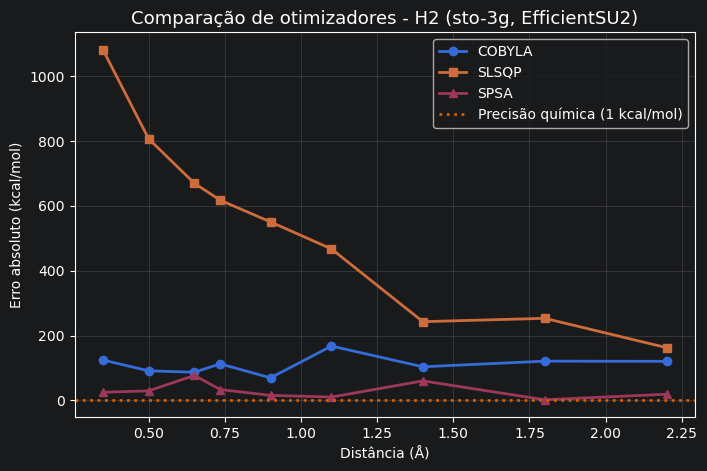

outputs/figures/slides_noisy/noisy_otimizadores_H2_6-31g_efficient_su2.png


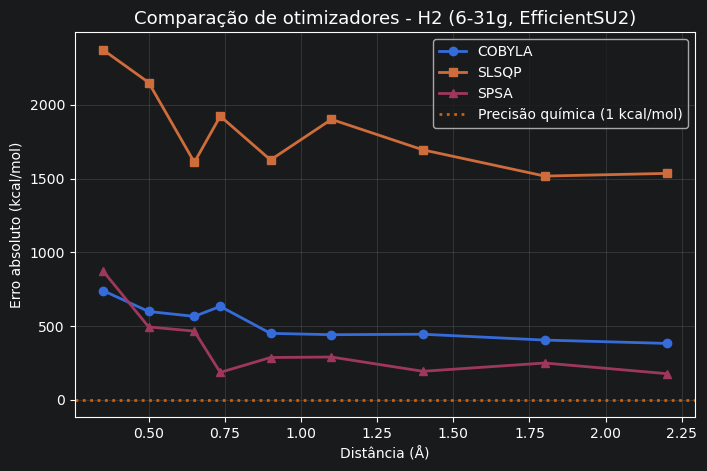

In [9]:
for molecule, basis, ansatz in [("H2", "sto-3g", "efficient_su2"), ("H2", "6-31g", "efficient_su2")]:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_optimizer_comparison(noisy_df, molecule=molecule, basis=basis, ansatz=ansatz, ax=ax)
    path = save_figure(fig, output_dir, f"noisy_otimizadores_{molecule}_{basis}_{ansatz}.png")
    print(path)
    plt.show()


## Chemical Accuracy and Runtime


outputs/figures/slides_noisy/noisy_taxa_precisao_quimica.png


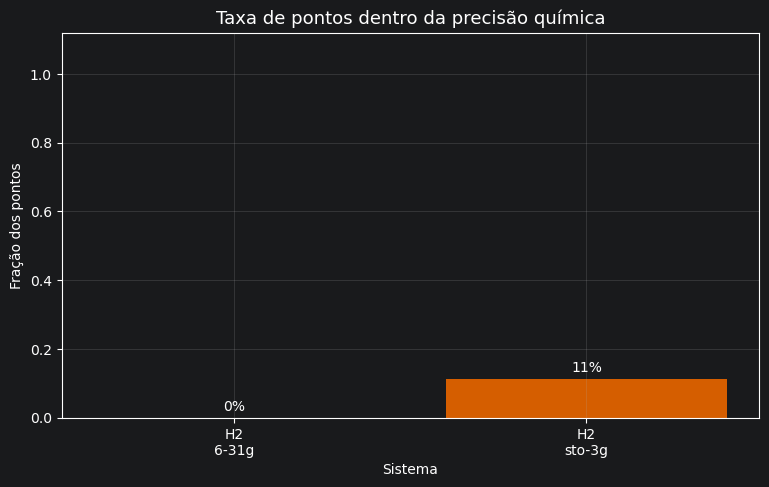

outputs/figures/slides_noisy/noisy_tempo_medio_configuracao.png


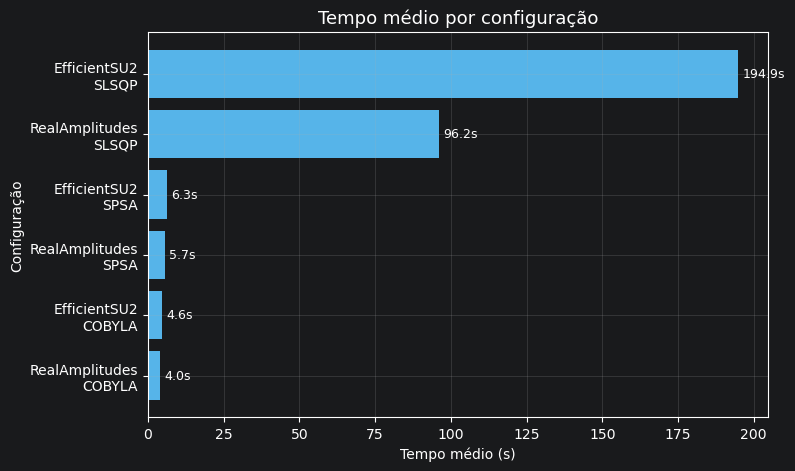

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_chemical_accuracy_rate(noisy_df, ax=ax)
path = save_figure(fig, output_dir, "noisy_taxa_precisao_quimica.png")
print(path)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_runtime_by_configuration(noisy_df, ax=ax)
path = save_figure(fig, output_dir, "noisy_tempo_medio_configuracao.png")
print(path)
plt.show()


## Generated Figures


In [11]:
for path in sorted(output_dir.glob("*.png")):
    print(path)


outputs/figures/slides_noisy/noisy_ansatz_H2_6-31g_cobyla.png
outputs/figures/slides_noisy/noisy_ansatz_H2_sto-3g_cobyla.png
outputs/figures/slides_noisy/noisy_dissociacao_H2_6-31g.png
outputs/figures/slides_noisy/noisy_dissociacao_H2_sto-3g.png
outputs/figures/slides_noisy/noisy_otimizadores_H2_6-31g_efficient_su2.png
outputs/figures/slides_noisy/noisy_otimizadores_H2_sto-3g_efficient_su2.png
outputs/figures/slides_noisy/noisy_taxa_precisao_quimica.png
outputs/figures/slides_noisy/noisy_tempo_medio_configuracao.png
outputs/figures/slides_noisy/noisy_vs_statevector_H2_6-31g.png
outputs/figures/slides_noisy/noisy_vs_statevector_H2_sto-3g.png
